In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

In [3]:
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torchvision import models

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [5]:
train_dir=r"C:\python code\deep learning\data1\train"
test_dir=r"C:\python code\deep learning\data1\test"
val_dir=r"C:\python code\deep learning\data1\val"

In [6]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = correct / len(y_pred) * 100
    return acc

In [7]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader

In [8]:

#print("--- Phase 2: Preprocessing & Augmentation ---")

img_height = 128
img_width = 128
batch_size = 32

# 1. Training Transforms (The "Messy" Data)
# Grayscale, Resize, Flip, Rotate, and convert to Tensor (0-1 scale)
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor() 
])

# 2. Validation & Test Transforms (The "Pure" Data)
# NO augmentation. Just Grayscale, Resize, and convert to Tensor.
val_test_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor()
])

# 3. Reload Datasets with the correct transforms
print("Applying specific transforms...")
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

# 4. Create DataLoaders
# num_workers=2 speeds up data loading by using multiple CPU cores
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

# 5. Calculate Class Weights (for imbalanced data)
print("Calculating class weights...")

train_labels = train_dataset.targets

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert the weights to a PyTorch tensor so our Loss Function can use it later
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32)


Applying specific transforms...
Calculating class weights...


In [9]:
img_size = 128
batch_size = 32

# 2. Training Transforms (The "Messy" Data)
# Includes Grayscale, Resize, Random Flips, and Rotations
train_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.Grayscale(num_output_channels=1), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor() ,
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 3. Validation & Test Transforms (The "Pure" Data)
# NO augmentation here. Just Grayscale and Resize.
val_test_transforms = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# 4. Apply the different transforms to the datasets
print("Applying specific transforms to datasets...")
train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=val_dir, transform=val_test_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transforms)

# 5. Create DataLoaders
# num_workers speeds up data loading by using multiple CPU cores
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# 6. Calculate Class Weights (to balance the AI's focus)
print("Calculating class weights...")
train_labels = train_dataset.targets
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Move the weights to the device as well!
class_weights= torch.tensor(class_weights_array, dtype=torch.float32).to(device)

Applying specific transforms to datasets...
Calculating class weights...


In [10]:
class Medical(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units * 2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(hidden_units * 2, hidden_units * 4, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        #self.flatten_size = self._get_flatten_size(input_shape)

        
        self.block4= nn.Sequential(
          nn.AdaptiveAvgPool2d((1,1)),
          nn.Flatten(),
          nn.Linear(hidden_units*4, output_shape)
        )

   
        
    def forward(self,x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        return x


In [11]:
model=Medical(input_shape=1,hidden_units=16,output_shape=3)

In [12]:
model.load_state_dict(torch.load("best_model.pth"))
model = model.to(device)

C:\Users\yashy\AppData\Local\Temp\ipykernel_10972\2148569672.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


In [13]:
loss_fn=nn.CrossEntropyLoss(weight=class_weights.to(device))

In [14]:
optimizer=torch.optim.Adam(model.parameters(),lr=0.003)

In [15]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    model.to(device)
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=torch.argmax(y_pred, dim=1)) # Go from logits -> pred labels


        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
    test_loss, test_acc = 0, 0
    model.to(device)
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y,
                y_pred=torch.argmax(test_pred, dim=1)) # Go from logits -> pred labels
            
        
        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
        return test_acc

In [16]:
epochs = 20
best_acc=0

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    
    train_step(
        model=model,
        data_loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn
    )

    
    
    val_acc=test_step(
        data_loader=val_loader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn
    )
    

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("🔥 Saved best model")


Epoch 1/20
Train loss: 0.47349 | Train accuracy: 73.98%
Test loss: 0.53718 | Test accuracy: 69.56%

🔥 Saved best model

Epoch 2/20
Train loss: 0.46874 | Train accuracy: 74.17%
Test loss: 0.50320 | Test accuracy: 73.84%

🔥 Saved best model

Epoch 3/20
Train loss: 0.46092 | Train accuracy: 74.89%
Test loss: 0.50110 | Test accuracy: 73.24%


Epoch 4/20
Train loss: 0.46171 | Train accuracy: 74.39%
Test loss: 0.47949 | Test accuracy: 74.70%

🔥 Saved best model

Epoch 5/20
Train loss: 0.45746 | Train accuracy: 74.78%
Test loss: 0.51887 | Test accuracy: 71.97%


Epoch 6/20
Train loss: 0.45353 | Train accuracy: 75.09%
Test loss: 0.47673 | Test accuracy: 73.22%


Epoch 7/20
Train loss: 0.45148 | Train accuracy: 74.95%
Test loss: 0.50142 | Test accuracy: 73.98%


Epoch 8/20
Train loss: 0.44807 | Train accuracy: 75.21%
Test loss: 0.48889 | Test accuracy: 73.28%


Epoch 9/20
Train loss: 0.45086 | Train accuracy: 75.12%
Test loss: 0.48184 | Test accuracy: 76.13%

🔥 Saved best model

Epoch 10/20
Tr

In [ ]:
torch.save(model.state_dict(), "model.pth")

In [17]:
test_step(
    data_loader=test_loader,
    model=model,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

Test loss: 0.48356 | Test accuracy: 74.45%



74.45130315500685

In [18]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

model.eval()

with torch.inference_mode():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        
        outputs = model(X)
        preds = torch.argmax(outputs, dim=1)
        
        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

In [20]:
cm = confusion_matrix(y_true, y_pred)


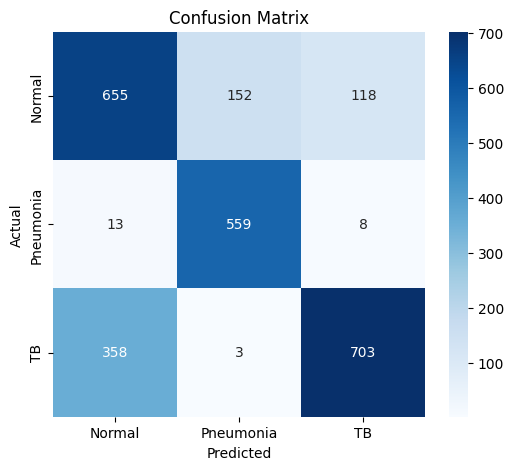

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Pneumonia','TB'],
            yticklabels=['Normal','Pneumonia','TB'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [24]:
from sklearn.metrics import classification_report

In [25]:
print(classification_report(
    y_true,
    y_pred,
    target_names=['Normal', 'Pneumonia', 'TB']
))

              precision    recall  f1-score   support

      Normal       0.64      0.71      0.67       925
   Pneumonia       0.78      0.96      0.86       580
          TB       0.85      0.66      0.74      1064

    accuracy                           0.75      2569
   macro avg       0.76      0.78      0.76      2569
weighted avg       0.76      0.75      0.74      2569

